# Task 1: Term Deposit Subscription Prediction (Bank Marketing)

## Objective
Predict whether a bank customer will subscribe to a term deposit as a result of a marketing campaign.

## Dataset Description
Bank Marketing Dataset (UCI) containing 41,188 rows and 21 columns including customer details (age, job, marital status, education), campaign information (contact type, duration, previous outcomes), and economic indicators. Target column 'y' indicates subscription (yes/no).

## Conclusion
Two classification models were trained on 41,188 customer records. Random Forest outperformed Logistic Regression (Accuracy: 91.7% vs 91.1%, F1-Score: 0.59 vs 0.52, AUC: 0.94 vs 0.93). The dataset was highly imbalanced (only ~11% subscriptions), making F1-Score the key metric. SHAP analysis revealed call duration as the strongest predictor, followed by economic indicators (nr.employed, emp.var.rate, euribor3m). Five individual predictions were explained using SHAP force plots, showing how each feature pushed predictions toward yes or no.

In [1]:
# importing Libraries
import numpy as np                      # for mathematical calculations
import pandas as pd                     # for handle data in tables, spredsheets or other formats
import seaborn as sns                   # for creating graphs and charts
import matplotlib.pyplot as plt         # base library for creating plots, seaborn uses it underneath


In [2]:
df = pd.read_csv('bank-additional-full.csv', sep=';')  # loading dataset, columns separated by semicolon
pd.set_option('display.max_columns', None)  # displaying all columns without truncation
df.head()  # displaying first 5 rows

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
print(df.shape)  # checking rows and columns
print(df.columns)  # displaying column names
df.isnull().sum()  # checking missing values

(41188, 21)
Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')


,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [4]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, ':', df[col].unique())  # displaying unique values of each text column to identify hidden missing values

job : ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']
marital : ['married' 'single' 'divorced' 'unknown']
education : ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']
default : ['no' 'unknown' 'yes']
housing : ['no' 'yes' 'unknown']
loan : ['no' 'yes' 'unknown']
contact : ['telephone' 'cellular']
month : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']
day_of_week : ['mon' 'tue' 'wed' 'thu' 'fri']
poutcome : ['nonexistent' 'failure' 'success']
y : ['no' 'yes']


In [5]:
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, ':', (df[col] == 'unknown').sum())  # counting unknown values per column

job : 330
marital : 80
education : 1731
default : 8597
housing : 990
loan : 990
contact : 0
month : 0
day_of_week : 0
poutcome : 0
y : 0


In [6]:
# replacing unknown values with mode of each column
for col in ['job', 'marital', 'education', 'default', 'housing', 'loan']:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

# verifying no unknown values are left
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, ':', (df[col] == 'unknown').sum())

job : 0
marital : 0
education : 0
default : 0
housing : 0
loan : 0
contact : 0
month : 0
day_of_week : 0
poutcome : 0
y : 0


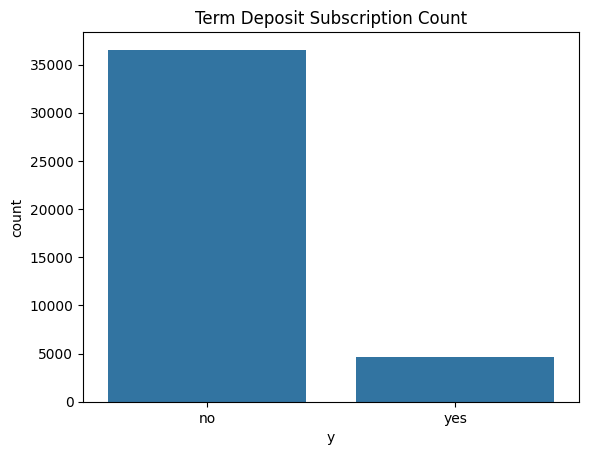

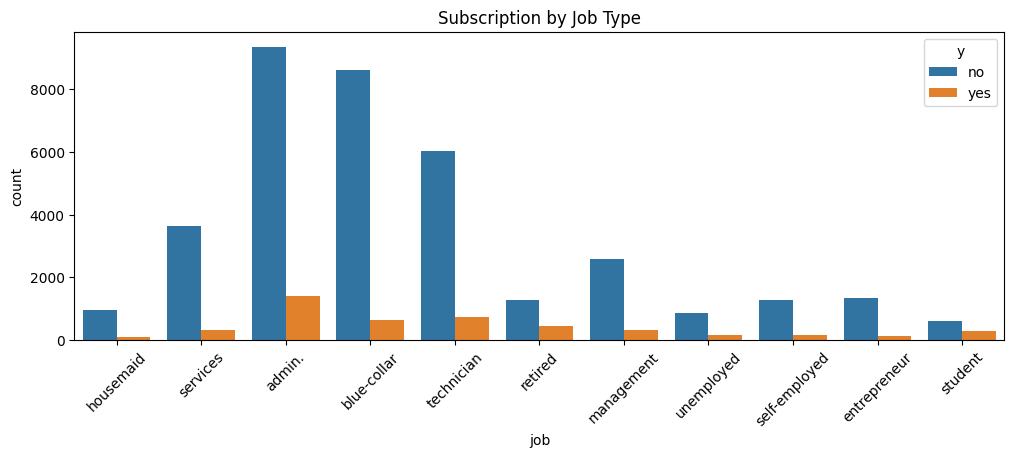

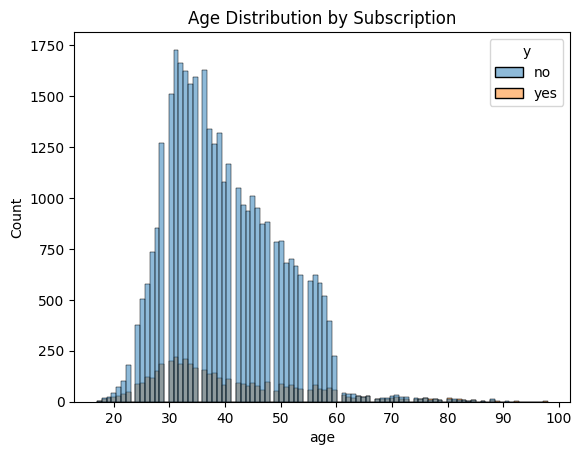

In [7]:
# countplot to see how many customers subscribed vs not
sns.countplot(data=df, x='y')
plt.title('Term Deposit Subscription Count')
plt.show()

# job vs subscription
plt.figure(figsize=(12,4))
sns.countplot(data=df, x='job', hue='y')
plt.title('Subscription by Job Type')
plt.xticks(rotation=45)
plt.show()

# age distribution
sns.histplot(data=df, x='age', hue='y')
plt.title('Age Distribution by Subscription')
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder  # importing LabelEncoder
le = LabelEncoder()  # creating encoder object

# encoding all text columns to numbers
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

df.head()  # verifying all columns are numeric now

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,261,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,0,0,0,1,6,1,149,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,1,0,1,6,1,226,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,151,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,1,1,6,1,307,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [9]:
from sklearn.model_selection import train_test_split  # importing train_test_split
X = df.drop('y', axis=1)  # input features
y = df['y']  # target column to predict
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # 80% train, 20% test

In [10]:
print(X_train.shape)  # verifying training data size (80% of rows)
print(X_test.shape)   # verifying testing data size (20% of rows)

(32950, 20)
(8238, 20)


In [11]:
from sklearn.linear_model import LogisticRegression  # importing logistic regression
lr_model = LogisticRegression(max_iter=5000, solver='liblinear')  # creating model object with more iterations
lr_model.fit(X_train, y_train)  # training the model
lr_pred = lr_model.predict(X_test)  # predicting on test data

In [12]:
from sklearn.ensemble import RandomForestClassifier  # importing random forest
rf_model = RandomForestClassifier(random_state=42)  # creating model with 100 trees
rf_model.fit(X_train, y_train)  # training the model
rf_pred = rf_model.predict(X_test)  # predicting on test data

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score  # importing evaluation metrics

print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))
print("Logistic Regression F1-Score:", f1_score(y_test, lr_pred))
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print("Random Forest F1-Score:", f1_score(y_test, rf_pred))

Logistic Regression Accuracy: 0.9115076474872542
Logistic Regression F1-Score: 0.5168986083499006
Random Forest Accuracy: 0.9168487496965283
Random Forest F1-Score: 0.5925044616299822


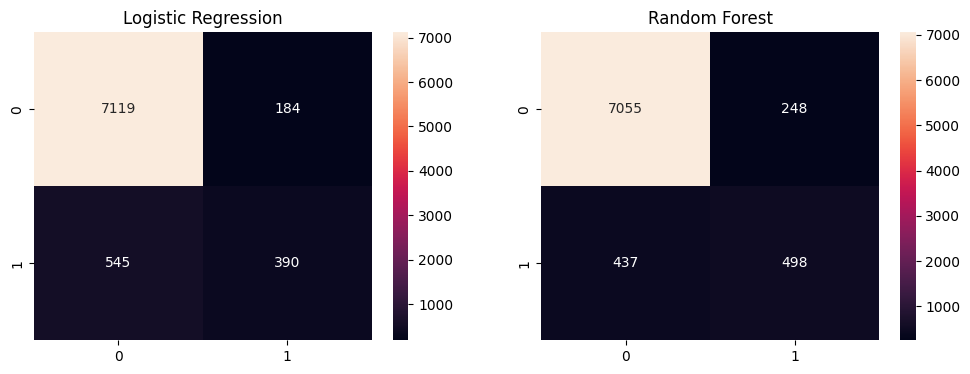

In [14]:
# confusion matrix for both models
fig, axes = plt.subplots(1, 2, figsize=(12,4))  # creating 2 plots side by side
sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', ax=axes[0])  # LR confusion matrix
axes[0].set_title('Logistic Regression')
sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=axes[1])  # RF confusion matrix
axes[1].set_title('Random Forest')
plt.show()

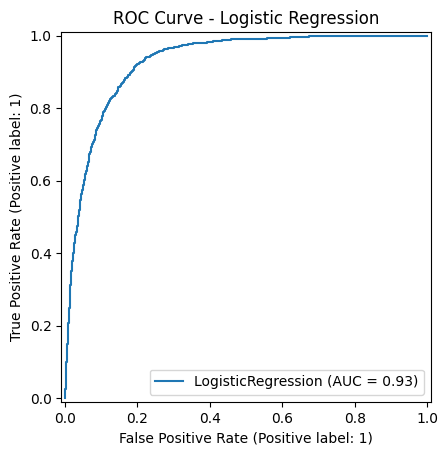

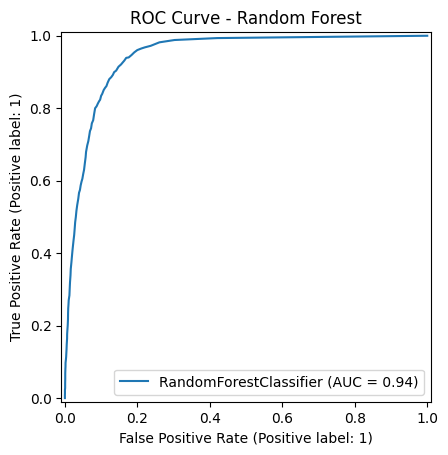

In [15]:
from sklearn.metrics import RocCurveDisplay  # importing ROC curve tool

RocCurveDisplay.from_estimator(lr_model, X_test, y_test)  # ROC for logistic regression
plt.title('ROC Curve - Logistic Regression')
plt.show()

RocCurveDisplay.from_estimator(rf_model, X_test, y_test)  # ROC for random forest
plt.title('ROC Curve - Random Forest')
plt.show()

In [16]:
!pip install shap  # installing shap library

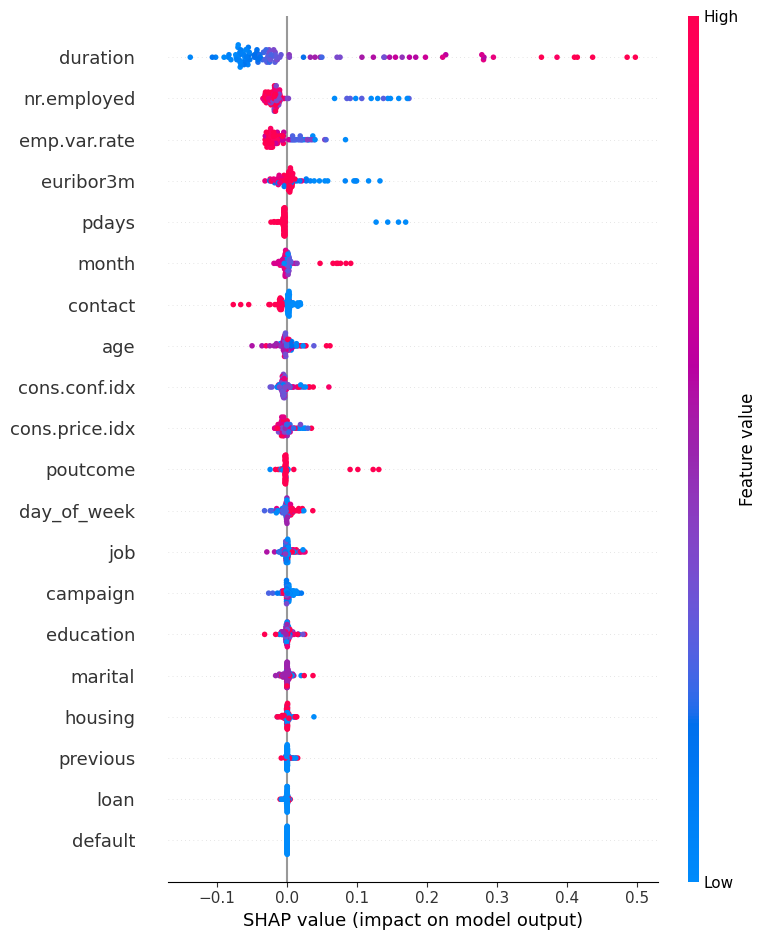

In [17]:
import shap  # importing shap for model explainability

explainer = shap.TreeExplainer(rf_model)  # creating explainer for random forest
shap_values = explainer.shap_values(X_test.iloc[:100])  # calculating shap values for first 100 test rows

shap.summary_plot(shap_values[:,:,1], X_test.iloc[:100])  # summary plot showing feature impact


Prediction 1: Actual = 0, Predicted = 0


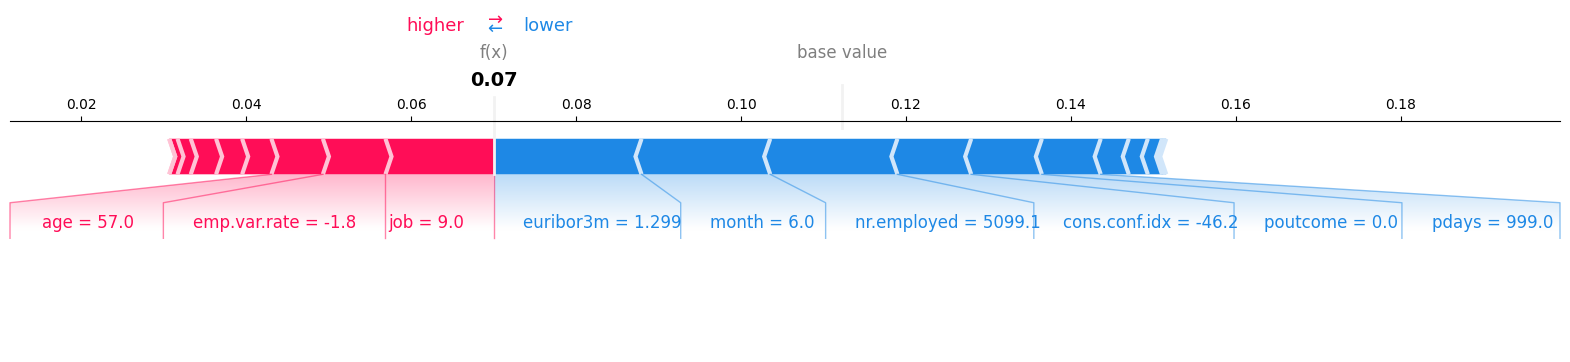


Prediction 2: Actual = 0, Predicted = 0


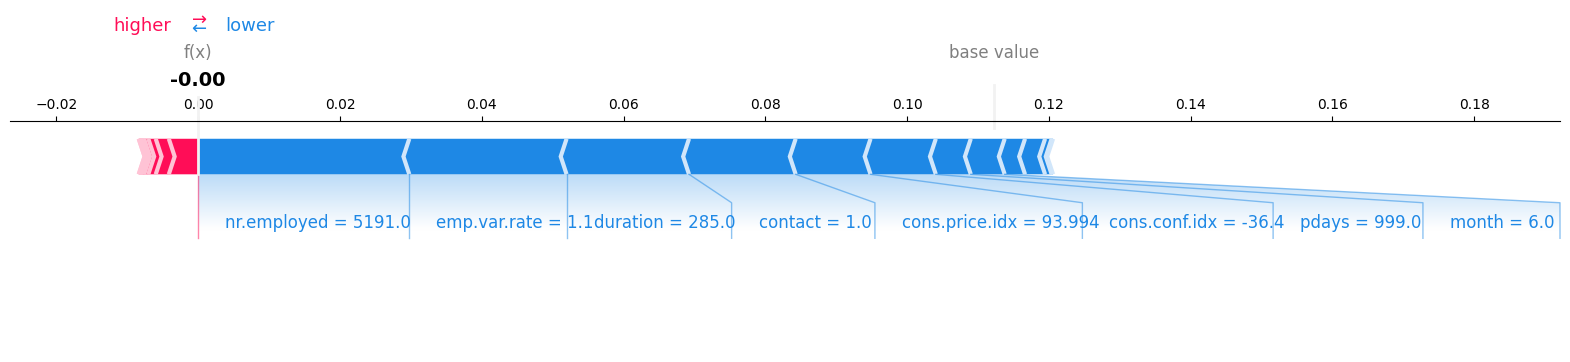


Prediction 3: Actual = 0, Predicted = 0


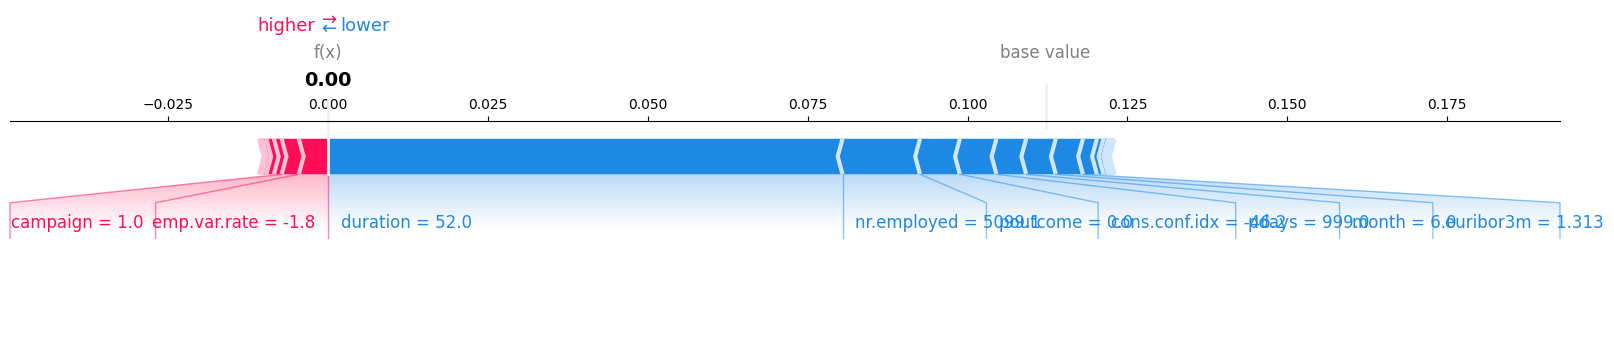


Prediction 4: Actual = 0, Predicted = 0


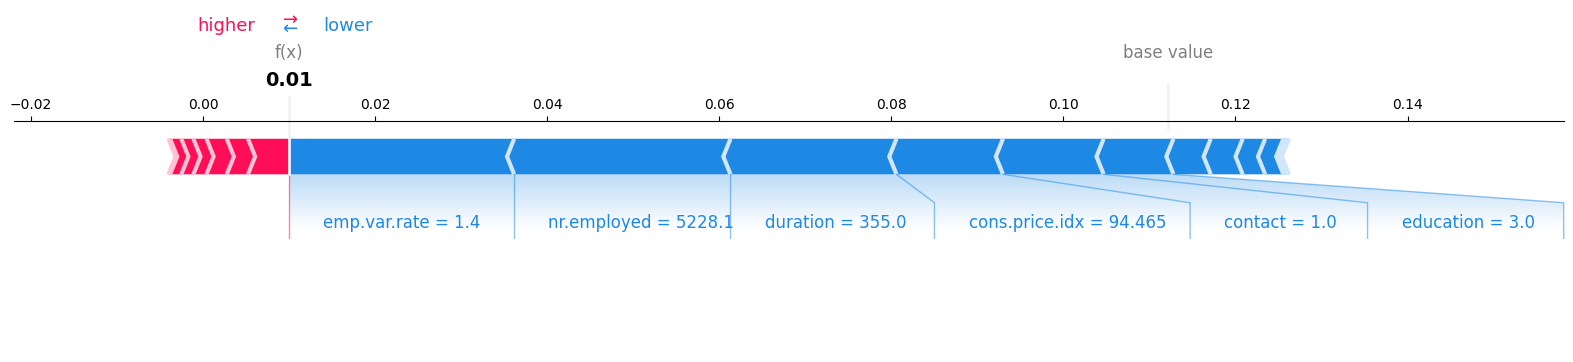


Prediction 5: Actual = 0, Predicted = 0


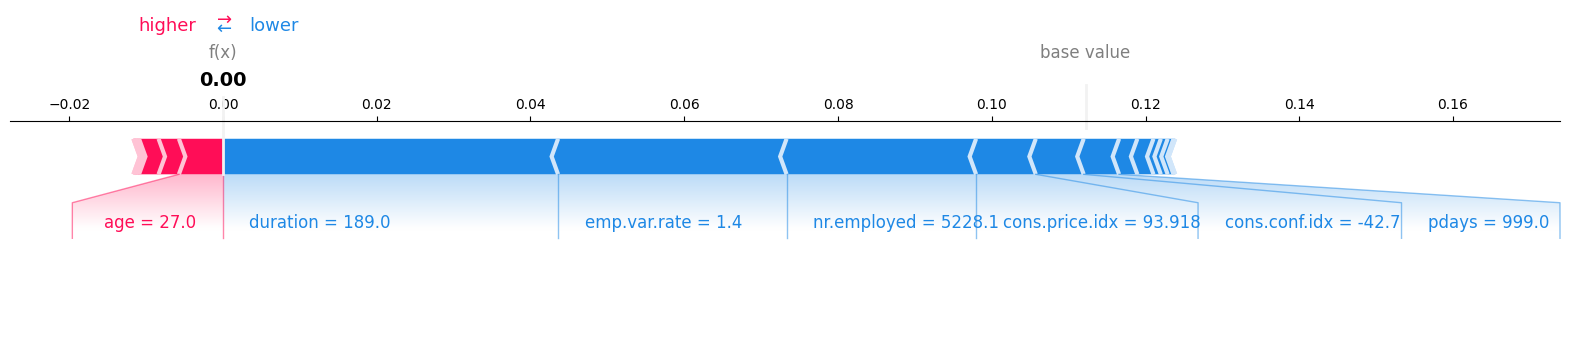

In [18]:
# explaining 5 individual predictions using SHAP force plots
shap.initjs()  # initializing javascript for plots

for i in range(5):
    print(f"\nPrediction {i+1}: Actual = {y_test.iloc[i]}, Predicted = {rf_pred[i]}")
    shap.plots.force(explainer.expected_value[1], shap_values[i,:,1], X_test.iloc[i], matplotlib=True)